<a href="https://colab.research.google.com/github/ShoaibAkhtar433/ML-Task1/blob/Prediction_of_Future_Stock_Prices__Task2.ipynb/Prediction_of_Future_Stock_Prices__Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing Libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Fetching Dataset using yfinance library
stock = yf.download("GOOGL", start="2023-01-01", end="2026-01-01")
stock

/tmp/ipykernel_7782/4044693588.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("GOOGL", start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2023-01-03,88.389473,90.303653,87.794385,88.855614,28131200
2023-01-04,87.357994,89.906927,86.554629,89.609383,34854800
2023-01-05,85.493393,86.852165,85.195857,86.752987,27194400
2023-01-06,86.624046,86.971183,84.164380,86.078559,41381500
2023-01-09,87.298485,89.311851,87.139800,87.635702,29003900
...,...,...,...,...,...
2025-12-24,313.869049,314.858343,311.700593,314.548563,10097400
2025-12-26,313.289459,314.868334,312.060314,314.258778,10899000


In [ ]:
# Adding Prediction Column
stock['Next_Close'] = stock['Close'].shift(-1)
stock

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,
Date,,,,,,
2023-01-03,88.389473,90.303653,87.794385,88.855614,28131200,87.357994
2023-01-04,87.357994,89.906927,86.554629,89.609383,34854800,85.493393
2023-01-05,85.493393,86.852165,85.195857,86.752987,27194400,86.624046
2023-01-06,86.624046,86.971183,84.164380,86.078559,41381500,87.298485
2023-01-09,87.298485,89.311851,87.139800,87.635702,29003900,87.695206
...,...,...,...,...,...,...
2025-12-24,313.869049,314.858343,311.700593,314.548563,10097400,313.289459
2025-12-26,313.289459,314.868334,312.060314,314.258778,10899000,313.339417


In [ ]:
# Drop Last Row (It has no next value)
stock = stock.iloc[:-1]
stock

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,
Date,,,,,,
2023-01-03,88.389473,90.303653,87.794385,88.855614,28131200,87.357994
2023-01-04,87.357994,89.906927,86.554629,89.609383,34854800,85.493393
2023-01-05,85.493393,86.852165,85.195857,86.752987,27194400,86.624046
2023-01-06,86.624046,86.971183,84.164380,86.078559,41381500,87.298485
2023-01-09,87.298485,89.311851,87.139800,87.635702,29003900,87.695206
...,...,...,...,...,...,...
2025-12-23,314.128876,314.718457,309.102415,309.412195,25478700,313.869049
2025-12-24,313.869049,314.858343,311.700593,314.548563,10097400,313.289459


In [ ]:
# Features (inputs)
X = stock[['Open', 'High', 'Low', 'Volume']]
X


Price,Open,High,Low,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,
2023-01-03,88.855614,90.303653,87.794385,28131200
2023-01-04,89.609383,89.906927,86.554629,34854800
2023-01-05,86.752987,86.852165,85.195857,27194400
2023-01-06,86.078559,86.971183,84.164380,41381500
2023-01-09,87.635702,89.311851,87.139800,29003900
...,...,...,...,...
2025-12-23,309.412195,314.718457,309.102415,25478700
2025-12-24,314.548563,314.858343,311.700593,10097400


In [ ]:
# Target (output)
Y = stock['Next_Close']
Y

,Next_Close
Date,
2023-01-03,87.357994
2023-01-04,85.493393
2023-01-05,86.624046
2023-01-06,87.298485
2023-01-09,87.695206
...,...
2025-12-23,313.869049
2025-12-24,313.289459
2025-12-26,313.339417


In [ ]:
# Splitting Data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
# Implementing Linear Regression Model
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Predicted Stock Prices
Y_pred = model.predict(X_test)
Y_pred

array([176.09973034, 174.22010674, 124.53598663, 136.71314552,
       139.37194929, 278.67536423, 165.93259688, 128.20571502,
       183.05326306, 319.6549075 , 122.3378826 , 149.68033928,
       140.75674428, 314.0427586 , 128.00875776, 150.62565241,
        89.69790413, 139.73954105, 177.29989391, 169.80454604,
       313.73707702, 190.55415956, 149.00903411, 157.37393477,
       105.21295803, 284.7279789 , 139.30836315, 157.60066366,
       133.72916098, 134.95363688, 174.86856153, 286.94155476,
       164.03854663, 169.0821955 , 178.75842715, 103.67983641,
       126.88808353, 160.96863126, 106.75332229, 321.58303771,
       104.39712595, 171.59918246,  91.49270558, 116.92919726,
       158.9452984 , 159.18517686, 192.45497882, 195.65684919,
       170.79211744, 158.0888274 ,  90.71345076, 189.41012041,
       178.75721789, 154.84018823, 180.64341643, 122.06878383,
       174.86139406, 104.77272158, 321.68327764, 104.3955514 ,
       136.97185606, 126.0469181 , 290.80003466, 273.21

In [ ]:
# Converting Predicted Prices from Array Form to DataFrame Column
Y_pred_df = pd.DataFrame(Y_pred, columns=['Predicted_Next_Close'])
display(Y_pred_df)

,Predicted_Next_Close
0,176.099730
1,174.220107
2,124.535987
3,136.713146
4,139.371949
...,...
146,116.498284
147,168.756243
148,283.405314
149,106.021021


In [ ]:
# Evaluation of Model
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared Error: ", mse)

Mean Squared Error:  11.883441047537273


In [ ]:
import numpy as np
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
print("RMSE: ", rmse)

RMSE:  3.447236726355948


<function matplotlib.pyplot.show(close=None, block=None)>

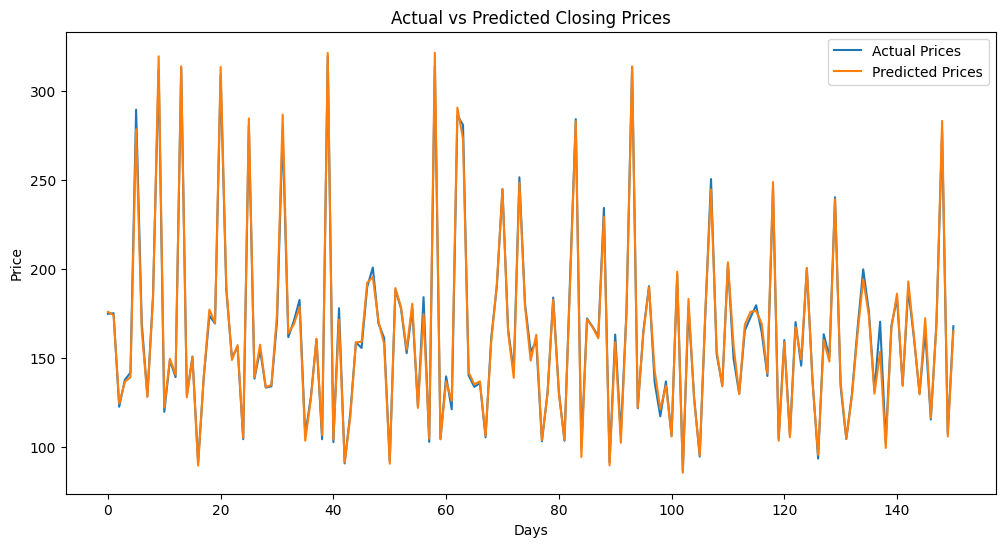

In [ ]:
# Putting Sizes to Diagram
plt.figure(figsize=(12, 6))

# Labeling Actual Prices to Y_test Values
plt.plot(Y_test.values, label='Actual Prices')

# Labeling Predited Prices to Y_pred Values
plt.plot(Y_pred, label='Predicted Prices')

# Generating a Box Showing Different Colors for Actual & Predicted Prices
plt.legend()

# Giving Title to the Diagram
plt.title("Actual vs Predicted Closing Prices")

# Showing x-asis 'Days' & y-axis 'Prices'
plt.xlabel('Days')
plt.ylabel('Price')

# Displaying tthe Final Graph
plt.show